# PLN — Embeddings de Palavras com Dados do #edtwt

Neste notebook, exploraremos representações vetoriais densas de palavras (*word embeddings*) utilizando um corpus real de posts do Twitter com a hashtag #edtwt.

1. **Word2Vec** — análise dos embeddings pré-computados no corpus de tweets, com cálculo de similaridade, busca semântica e agrupamento.
2. **spaCy (vetores pré-treinados)** — uso de embeddings genéricos já treinados em grandes corpora de língua portuguesa, com comparação entre os dois modelos.

---

## Instruções de Uso

- **Execute as células em ordem**, de cima para baixo.
- Após a célula de instalação, pode ser necessário **reiniciar o kernel** do Jupyter para que as dependências sejam reconhecidas.
- Certifique-se de que os arquivos `entrega_3.csv` e `entrega_3_word2vec_features.json` estejam no mesmo diretório deste notebook.

In [1]:
%pip install pandas numpy seaborn matplotlib plotly scikit-learn gensim nltk spacy --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import ast
import json
import os
import nltk

from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')
nltk.download('punkt_tab', quiet=True)

sns.set_theme(style='whitegrid', context='notebook')
%matplotlib inline

# Word2Vec

Um dos modelos distribuídos mais influentes é o Word2Vec (Mikolov et al., 2013). Ele introduziu duas arquiteturas simples de rede neural para gerar embeddings: CBOW (Continuous Bag-of-Words) e Skip-Gram.

No CBOW, o objetivo é, dada uma janela de palavras de contexto, prever a palavra central; já no Skip-Gram, faz-se o inverso — dada a palavra central, prever as palavras de contexto. Os pesos aprendidos no vetor de projeção passam a ser as representações densas das palavras.

**Atenção:** Neste notebook, utilizamos os vetores Word2Vec que já foram pré-computados e armazenados no CSV (`vetor_medio_word2vec`). Como tweets são textos curtos que compartilham muitas palavras comuns (ex: "edtwt", URLs), os vetores médios resultantes possuem similaridade de cosseno próxima de 1.0 entre quase todos os documentos. Para revelar as diferenças semânticas reais, aplicamos **centralização pela média** (mean-centering): subtraímos o vetor médio global de cada documento, o que remove o componente dominante comum e destaca as variações individuais.

## Carregamento dos Dados

O dataset `entrega_3.csv` contém tweets coletados com a hashtag #edtwt, já processados com tokenização, remoção de stopwords, stemming e normalização. O arquivo `entrega_3_word2vec_features.json` contém os hiperparâmetros do modelo Word2Vec utilizado no processamento original.

In [3]:
DATA_DIR = os.getcwd()
csv_path = os.path.join(DATA_DIR, 'entrega_3.csv')
json_path = os.path.join(DATA_DIR, 'entrega_3_word2vec_features.json')

for p in [csv_path, json_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Arquivo não encontrado: {p}")

In [4]:
df = pd.read_csv(csv_path)
print(f"Dataset: {df.shape[0]} tweets, {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")
df[['text', 'normalizacao_re', 'tokens_word2vec', 'vetor_medio_word2vec']].head()

Dataset: 2815 tweets, 35 colunas
Colunas: ['search_date', 'id', 'url', 'text', 'source', 'created_at', 'lang', 'retweet_count', 'reply_count', 'like_count', 'quote_count', 'view_count', 'bookmark_count', 'conversation_id', 'in_reply_to_id', 'in_reply_to_user_id', 'in_reply_to_username', 'is_reply', 'is_limited_reply', 'author_id', 'author_name', 'author_username', 'author_url', 'author_followers', 'author_following', 'hashtags', 'urls', 'mentions', 'tokenizacao_nltk', 'remocao_stopwords_spacy', 'stemming_nltk', 'normalizacao_re', 'features_tfidf_sklearn', 'tokens_word2vec', 'vetor_medio_word2vec']


,text,normalizacao_re,tokens_word2vec,vetor_medio_word2vec
0,Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎\n．☆．。．:*･ﾟ\n\...,refeiçõ hj wieiad gent esquec tir fot almoc ar...,"[""refeiçõ"", ""hj"", ""wieiad"", ""gent"", ""esquec"", ...","[-0.112007, 0.145861, -0.010249, 0.117236, 0.0..."
1,em quanto tempo vocês tiveram resultados notáv...,result not academ edtwt gymtwt gymgirl,"[""result"", ""not"", ""academ"", ""edtwt"", ""gymtwt"",...","[-0.06753, 0.086301, -0.005118, 0.073525, 0.00..."
2,A geladeira do edtwt que mora sozinha \n#edtwt...,geladeir edtwt mor sozinh edtwt nofood diet ze...,"[""geladeir"", ""edtwt"", ""mor"", ""sozinh"", ""edtwt""...","[-0.135215, 0.175155, -0.010368, 0.140096, 0.0..."
3,"Talvez, só talvez eu tenha dismofia corporal. ...",tenh dismof corporal amig jur q tính corp vei ...,"[""tenh"", ""dismof"", ""corporal"", ""amig"", ""jur"", ...","[-0.122911, 0.159895, -0.010451, 0.134275, 0.0..."
4,"cade a comunidade #edtwt ? quwro amizades, vam...",cad comun edtwt quwr amizad vam motiv bbzud,"[""cad"", ""comun"", ""edtwt"", ""quwr"", ""amizad"", ""v...","[-0.074613, 0.097484, -0.009679, 0.080022, 0.0..."


In [5]:
with open(json_path, 'r') as f:
    w2v_config = json.load(f)

print("Configuração do modelo Word2Vec original:")
for k, v in w2v_config.items():
    if k != 'vocabulario_amostra':
        print(f"  {k}: {v}")

Configuração do modelo Word2Vec original:
  vocabulario_tamanho: 5840
  vector_size: 100
  window: 5
  min_count: 1
  sg: 0
  arquitetura: CBOW


## Extração e Diagnóstico dos Vetores

Carregamos os vetores pré-computados e verificamos a distribuição de similaridade. Quando tweets curtos compartilham muitas palavras comuns, os vetores médios tendem a ser quase idênticos. A centralização pela média resolve esse problema.

In [6]:
def parse_vetor(vetor_str):
    if pd.isna(vetor_str):
        return None
    try:
        return np.array(ast.literal_eval(vetor_str), dtype=np.float32)
    except (ValueError, SyntaxError):
        return None

def parse_tokens(token_str):
    if pd.isna(token_str):
        return []
    try:
        result = ast.literal_eval(token_str)
        return result if isinstance(result, list) else []
    except (ValueError, SyntaxError):
        return []

df['vetor_parsed'] = df['vetor_medio_word2vec'].apply(parse_vetor)
df['tokens_parsed'] = df['tokens_word2vec'].apply(parse_tokens)

valid_mask = df['vetor_parsed'].notna()
vetores = np.stack(df.loc[valid_mask, 'vetor_parsed'].values)
documentos = df.loc[valid_mask, 'text'].values
tokens_lista = df.loc[valid_mask, 'tokens_parsed'].values

print(f"Vetores carregados: {vetores.shape}")
print(f"Dimensão de cada vetor: {vetores.shape[1]}")
print(f"Total de documentos válidos: {len(documentos)}")

Vetores carregados: (2815, 100)
Dimensão de cada vetor: 100
Total de documentos válidos: 2815


In [7]:
sim_raw = cosine_similarity(vetores)
upper_raw = sim_raw[np.triu_indices_from(sim_raw, k=1)]

print('=== Similaridade de Cosseno ORIGINAL (sem centralização) ===')
print(f'  Média: {upper_raw.mean():.6f}')
print(f'  Desvio padrão: {upper_raw.std():.6f}')
print(f'  Mínimo: {upper_raw.min():.4f}  |  Máximo: {upper_raw.max():.4f}')
print(f'  Mediana: {np.median(upper_raw):.6f}')
print()
print('Todos os valores estão muito próximos de 1.0, indicando que os vetores')
print('possuem um componente dominante comum (palavras frequentes compartilhadas).')
print('A similaridade direta não consegue distinguir documentos entre si.')

=== Similaridade de Cosseno ORIGINAL (sem centralização) ===
  Média: 0.999767
  Desvio padrão: 0.000394
  Mínimo: 0.9806  |  Máximo: 1.0000
  Mediana: 0.999817

Todos os valores estão muito próximos de 1.0, indicando que os vetores
possuem um componente dominante comum (palavras frequentes compartilhadas).
A similaridade direta não consegue distinguir documentos entre si.


In [9]:
vetor_medio_global = vetores.mean(axis=0)
vetores_centralizados = vetores - vetor_medio_global

sim_cent = cosine_similarity(vetores_centralizados)
upper_cent = sim_cent[np.triu_indices_from(sim_cent, k=1)]

print('=== Similaridade de Cosseno CENTRALIZADA (após mean-centering) ===')
print(f'  Média: {upper_cent.mean():.6f}')
print(f'  Desvio padrão: {upper_cent.std():.6f}')
print(f'  Mínimo: {upper_cent.min():.4f}  |  Máximo: {upper_cent.max():.4f}')
print(f'  Mediana: {np.median(upper_cent):.6f}')
print()
print('Após a centralização, a similaridade varia de -1 a +1 com')
print('distribuição centrada em 0, revelando as diferenças semânticas reais.')

=== Similaridade de Cosseno CENTRALIZADA (após mean-centering) ===
  Média: 0.002290
  Desvio padrão: 0.932912
  Mínimo: -0.9999  |  Máximo: 1.0000
  Mediana: 0.021035

Após a centralização, a similaridade varia de -1 a +1 com
distribuição centrada em 0, revelando as diferenças semânticas reais.


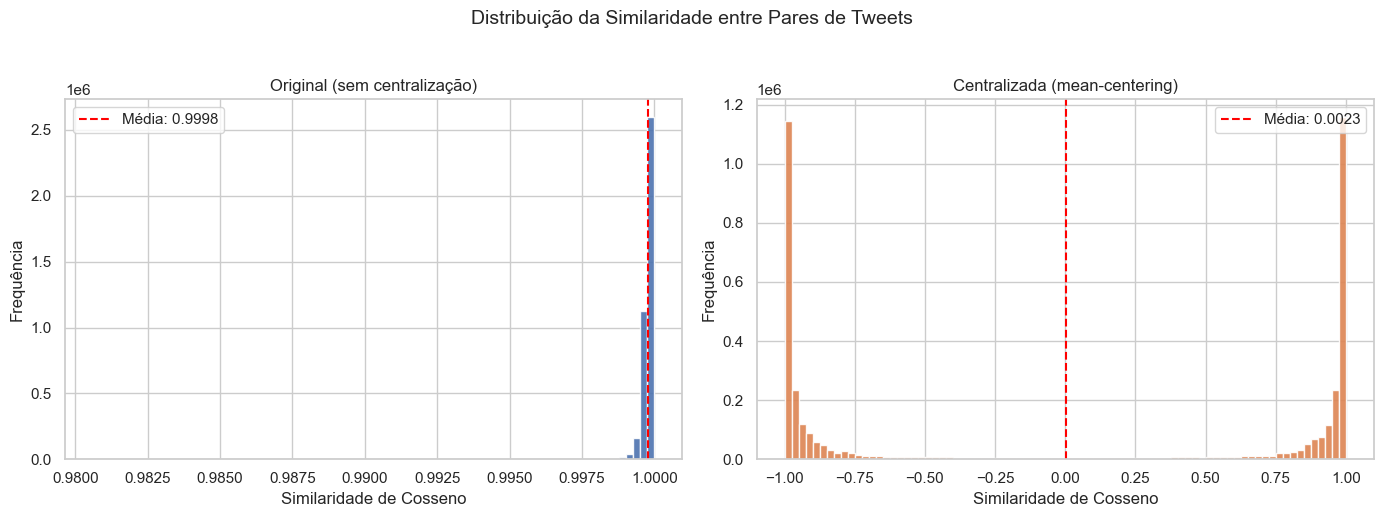

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(upper_raw, bins=80, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].axvline(upper_raw.mean(), color='red', linestyle='--', label=f'Média: {upper_raw.mean():.4f}')
axes[0].set_title('Original (sem centralização)', fontsize=12)
axes[0].set_xlabel('Similaridade de Cosseno')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].hist(upper_cent, bins=80, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(upper_cent.mean(), color='red', linestyle='--', label=f'Média: {upper_cent.mean():.4f}')
axes[1].set_title('Centralizada (mean-centering)', fontsize=12)
axes[1].set_xlabel('Similaridade de Cosseno')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.suptitle('Distribuição da Similaridade entre Pares de Tweets', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

## Heatmap de Similaridade Centralizada (Amostra)

Visualizamos uma amostra aleatória de 20 tweets no heatmap. Com os vetores centralizados, as diferenças semânticas ficam visíveis: valores positivos indicam similaridade acima da média, valores negativos indicam dissimilaridade.

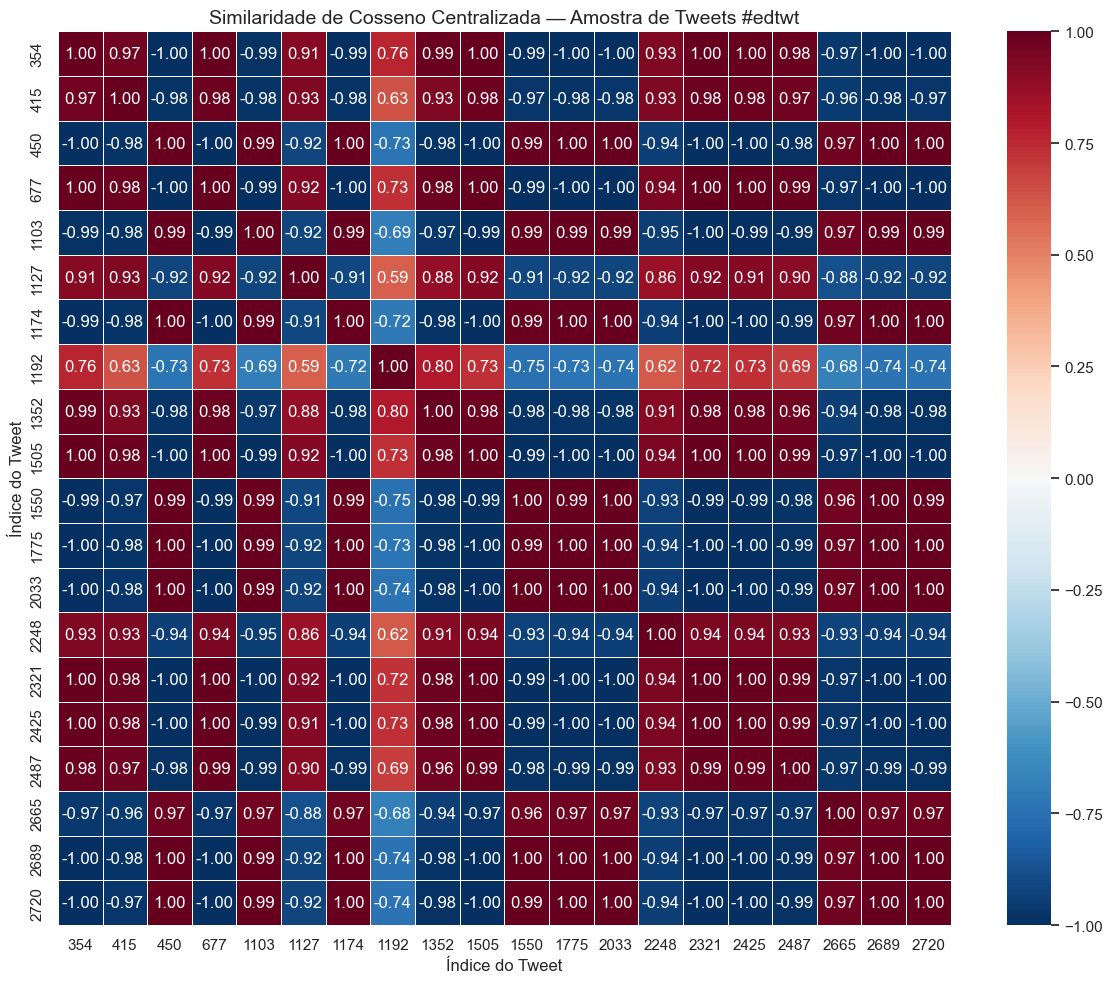

In [11]:
np.random.seed(42)
n_amostra = min(20, len(documentos))
indices_amostra = np.sort(np.random.choice(len(documentos), size=n_amostra, replace=False))

matriz_amostra = sim_cent[np.ix_(indices_amostra, indices_amostra)]
labels = [str(i) for i in indices_amostra]

plt.figure(figsize=(12, 10))
sns.heatmap(
    matriz_amostra,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=.5,
    xticklabels=labels,
    yticklabels=labels,
    vmin=-1, vmax=1
)
plt.title('Similaridade de Cosseno Centralizada — Amostra de Tweets #edtwt', fontsize=14)
plt.xlabel('Índice do Tweet', fontsize=12)
plt.ylabel('Índice do Tweet', fontsize=12)
plt.tight_layout()
plt.show()

### verificar valores absolutos/extremos
### vinte mais semelhantes
### gráficos de dispersão

### bert: mesma pipeline

In [12]:
print('Tweets da amostra:\n')
for i in indices_amostra:
    texto = documentos[i].replace('\n', ' ')[:90]
    print(f'  [{i}] {texto}{"..." if len(documentos[i]) > 90 else ""}')

Tweets da amostra:

  [354] Fui me pesar e tô com 77 kg #fatspo #feederism #edtwt https://t.co/haFNW9k57M
  [415] uma pequena dica não óbvia para muitos, se você ainda come demais, quando vc ta comendo, v...
  [450] Busco mutis otra vez  arriba los edgys #shedtwt #edtwt #obstwt de todo menos pedotwt o zot...
  [677] dando uma de #edtwt pq eu to com mt fome pra jantar mas já passei as calorias do dia hoje ...
  [1103] quando eu pensar em comer vou pensar nela, tão bebezinha, pequena e delicada, a winter é m...
  [1127] Eu so vou conseguir mudar m8nha vida de verdade quando eu for magra, porquê existem duas v...
  [1174] amigos do #edtwt indicação de site pra vocês (se vcs não conhecerem) tem vaaaarias receita...
  [1192] é galera, eu oficialmente entrei na casa dos 70 quilos, eu tô muito feliz 😭😭😭🫶🫶🫶🎉🎉 #edtwt ...
  [1352] Café da manhã💗 ~94 kcal &gt;&lt; #edtwt https://t.co/sONafkX4Yh
  [1505] @ryanmaluco vai ter #edtwt hoje
  [1550] vomitei meu almoço, posso fazer parte do #edtwt e ser

## Recomendação por Similaridade Semântica

Buscamos tweets mais similares a uma consulta usando os vetores centralizados. A consulta também é centralizada em relação ao mesmo vetor médio global, garantindo comparabilidade.

In [13]:
model_w2v = Word2Vec(
    sentences=[t for t in tokens_lista if len(t) > 0],
    vector_size=w2v_config.get('vector_size', 100),
    window=w2v_config.get('window', 5),
    min_count=w2v_config.get('min_count', 1),
    workers=4,
    sg=w2v_config.get('sg', 0)
)
print(f"Modelo Word2Vec treinado com {len(model_w2v.wv.index_to_key)} palavras.")

Modelo Word2Vec treinado com 5840 palavras.


In [36]:
def buscar_tweets(consulta, model, documentos, vetores_cent, vetor_medio_global, num_resultados=10):
    tokens_busca = word_tokenize(consulta.lower())
    vetores_palavras = [model.wv[t] for t in tokens_busca if t in model.wv]

    if not vetores_palavras:
        print(f"Aviso: Nenhuma palavra de '{consulta}' encontrada no vocabulário.")
        print(f"Tokens buscados: {tokens_busca}")
        return pd.DataFrame({'Tweet': [], 'Similaridade': []})

    vetor_busca_bruto = np.mean(vetores_palavras, axis=0)
    vetor_busca_cent = vetor_busca_bruto - vetor_medio_global

    similaridades = cosine_similarity(vetor_busca_cent.reshape(1, -1), vetores_cent)[0]
    indices_ranqueados = np.argsort(similaridades)[::-1]

    pd.set_option('display.max_colwidth', None)

    resultados = pd.DataFrame({
        'Tweet': [documentos[i].replace('\n', ' ')[:1000] for i in indices_ranqueados[:num_resultados]],
        'Similaridade': similaridades[indices_ranqueados[:num_resultados]]
    })
    return resultados

termo = input("Digite os termos de busca: ")

resultados = buscar_tweets(termo, model_w2v, documentos, vetores_centralizados, vetor_medio_global)
if not resultados.empty:
    print(f'\nTop {len(resultados)} resultados para "{termo}":')
resultados


Top 10 resultados para "vomit":


,Tweet,Similaridade
0,"meninas, hj eu provavelmente vou vomitar &gt;////&lt;. #EDTWT",0.757703
1,"Oi gente eu era da comunidade do edtwt a uns anos atras, mas fiquei um tempo de recovery mas essa merda de transtorno nunca vai embora ne, enfim perdi minha conta antiga e agora vou fazer essa para postar bc comidinhas etc https://t.co/hUpgQKaaXn",0.745815
2,"vomitei meu almoço, posso fazer parte do #edtwt e ser rei dos esqueletos agora???",0.740367
3,acabei de vomitar meu almoço pau no cu do recovery,0.740018
4,"Vamos deixar o ""fofocas &gt;&gt;&gt;EDTWT&lt;&lt;&lt;"" ser só sobre o ed, e não sobre assuntos pessoais q não são da nossa conta? Obgd",0.740004
5,"não consigo vomitar de jeito nenhum, alguém me ajuda por favor? #edtwt",0.739817
6,@lalisarockstr @OEstagiari0 chegou nas frequentadoras do #edtwt kkkk vai lá vomitar teu almoço gordinha,0.738264
7,Hoje vai ser a primeira vez que vou fazer um jejum de 16h. Mas perder o costume de tomar café da manhã está sendo um desafio kkkk. Com o tempo eu me acostumo? #edtwt,0.737308
8,"acho interessante adicionar que não sou novo no edtwt, já tive uma conta alguns anos atrás, só tinha entrado em recovery",0.736771
9,"oi gnt não sou nova no #edtwt mas tirei a @lesserathins do meu celular quando fiz recovery e meio que perdi a senha, queria moots novos😝",0.736729


## Agrupamento (Clustering) com KMeans

Aplicamos KMeans nos **vetores centralizados** para agrupar os tweets em clusters temáticos. A centralização garante que o algoritmo identifique grupos baseados nas diferenças semânticas, não no componente comum compartilhado.

In [15]:
num_clusters = 5

kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
kmeans.fit(vetores_centralizados)

df_cluster = pd.DataFrame({'Tweet': documentos, 'Cluster': kmeans.labels_})

print(f'Agrupamento com {num_clusters} clusters:\n')
for c in range(num_clusters):
    cluster = df_cluster[df_cluster['Cluster'] == c]
    print(f'  Cluster {c} ({len(cluster)} tweets):')
    for s in cluster['Tweet'].head(3):
        print(f'    - {s.replace(chr(10), " ")[:100]}')
    print()

Agrupamento com 5 clusters:

  Cluster 0 (511 tweets):
    - em quanto tempo vocês tiveram resultados notáveis na academia ?  #edtwt #gymtwt #gymgirl
    - cade a comunidade #edtwt ? quwro amizades, vamos nos motivas bbzudos !
    - oi pra quem nao sabe eu sou tarologa e quem der rt nessa thread ganha uma perguntinha de sim/nao com

  Cluster 1 (1058 tweets):
    - Refeições de hj! #wieiad ₍ᐢ. .ᐢ₎ ．☆．。．:*･ﾟ  Gente eu esqueci de tirar foto do almoço, mas foi arroz 
    - A geladeira do edtwt que mora sozinha  #edtwt #nofood  #diet #zerosugar https://t.co/SRvInSbGuj
    - Talvez, só talvez eu tenha dismofia corporal.  Uma amiga que eu jurava q tínhamos o mesmo corpo veio

  Cluster 2 (28 tweets):
    - @vernoncinefilo ???? te querem no #edtwt
    - @MarielAiex Mais uma pro #edtwt
    - @ywsvul se pesem #edtwt

  Cluster 3 (937 tweets):
    - Amo ver comidinhas do #edtwt 🤲
    - ︶ ⏝ ︶ ୨୧ ︶ ⏝ ︶ |                    ALMOÇO.  |            Peso  atual  ::  52kg  . |                
    - ︶ ⏝ 

## Visualização 2D com t-SNE e PCA 3D

Reduzimos a dimensionalidade dos vetores centralizados para 2D (t-SNE) e 3D (PCA), permitindo visualizar os clusters. Como a grande maioria da variância (>99%) está na primeira componente PCA, o t-SNE oferece uma visualização mais informativa.

In [16]:
pca_3d = PCA(n_components=3)
vetores_pca = pca_3d.fit_transform(vetores_centralizados)

var_exp = pca_3d.explained_variance_ratio_
print(f'Variância explicada: PC1={var_exp[0]:.2%}, PC2={var_exp[1]:.2%}, PC3={var_exp[2]:.2%}')
print(f'Variância total explicada (3 PCs): {var_exp.sum():.2%}')

Variância explicada: PC1=99.64%, PC2=0.14%, PC3=0.03%
Variância total explicada (3 PCs): 99.82%


In [17]:
perplexity = min(30, len(documentos) // 5)
tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, n_iter=1000)
vetores_tsne = tsne.fit_transform(vetores_centralizados)

plot_df = pd.DataFrame({
    't-SNE 1': vetores_tsne[:, 0],
    't-SNE 2': vetores_tsne[:, 1],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig = px.scatter(
    plot_df, x='t-SNE 1', y='t-SNE 2', color='Cluster',
    title=f't-SNE: Clusters de Tweets #edtwt ({num_clusters} clusters)',
    hover_data={'t-SNE 1': ':.2f', 't-SNE 2': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig.update_traces(marker=dict(size=4, opacity=0.7))
fig.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
pca_df = pd.DataFrame({
    'PCA 1': vetores_pca[:, 0],
    'PCA 2': vetores_pca[:, 1],
    'PCA 3': vetores_pca[:, 2],
    'Cluster': df_cluster['Cluster'].astype(str),
    'Tweet': [t.replace('\n', ' ')[:60] + ('...' if len(t) > 60 else '') for t in documentos]
})

fig_3d = px.scatter_3d(
    pca_df,
    x='PCA 1', y='PCA 2', z='PCA 3',
    color='Cluster',
    title=f'PCA 3D: Clusters de Tweets #edtwt ({num_clusters} clusters)',
    hover_data={'PCA 1': ':.2f', 'PCA 2': ':.2f', 'PCA 3': ':.2f', 'Cluster': True, 'Tweet': True},
    width=900, height=700
)
fig_3d.update_traces(marker=dict(size=3, opacity=0.7))
fig_3d.show()

# Utilizando vetores pré-treinados com spaCy

Neste exemplo, utilizamos a biblioteca spaCy com o modelo pré-treinado pt_core_news_lg, que contém embeddings de palavras em português com 300 dimensões, treinados sobre grandes corpora.

Esses embeddings foram obtidos por meio de técnicas como Word2Vec, GloVe ou similares, treinadas em textos extensos como Wikipedia, notícias e dados da web em português. Eles permitem que cada palavra seja representada por um vetor denso, em que a proximidade no espaço vetorial corresponde a similaridade semântica.

**O Word2Vec gera embeddings a partir de um corpus customizado, permitindo aprender representações específicas ao domínio dos dados, enquanto os modelos pré-treinados do spaCy fornecem embeddings genéricos já treinados em grandes corpora de língua portuguesa, prontos para uso imediato sem necessidade de reprocessamento.**

In [ ]:
import spacy
!python -m spacy download pt_core_news_lg --quiet

In [ ]:
nlp = spacy.load('pt_core_news_lg')

doc = nlp("O gato está dormindo no sofá.")
print("Dimensão do vetor em spaCy:", len(doc[1].vector))
print("Similaridade spaCy entre 'gato' e 'sofá':", doc[1].similarity(doc[-2]))

palavra1 = nlp("felino")[0]
palavra2 = nlp("gato")[0]
print("Similaridade entre 'felino' e 'gato':", palavra1.similarity(palavra2))

## Comparando: Word2Vec (Corpus #edtwt) vs. spaCy (Pré-treinado)

Vetorizamos uma amostra de tweets com o spaCy e comparamos as matrizes de similaridade. O spaCy, treinado em corpora gerais de português, produz vetores mais diferenciados entre documentos. Para comparação justa, centralizamos ambos.

In [ ]:
def vetor_medio_spacy(texto, nlp_model):
    doc = nlp_model(texto)
    vetores = [t.vector for t in doc if t.has_vector and not t.is_stop and not t.is_punct]
    if not vetores:
        vetores = [t.vector for t in doc if t.has_vector]
    if not vetores:
        return np.zeros(nlp_model.vocab.vectors.shape[1])
    return np.mean(vetores, axis=0)

np.random.seed(42)
n_spacy = min(200, len(documentos))
idx_spacy = np.sort(np.random.choice(len(documentos), size=n_spacy, replace=False))

tweets_spacy = [documentos[i] for i in idx_spacy]
vetores_spacy = np.array([vetor_medio_spacy(t, nlp) for t in tweets_spacy])
vetores_w2v_amostra = vetores_centralizados[idx_spacy]

# Centralizar também os vetores spaCy
vetores_spacy_cent = vetores_spacy - vetores_spacy.mean(axis=0)

sim_w2v = cosine_similarity(vetores_w2v_amostra)
sim_spacy = cosine_similarity(vetores_spacy_cent)

w2v_upper = sim_w2v[np.triu_indices_from(sim_w2v, k=1)]
spacy_upper = sim_spacy[np.triu_indices_from(sim_spacy, k=1)]

print(f'Word2Vec (centralizado):  média={w2v_upper.mean():.4f}, std={w2v_upper.std():.4f}')
print(f'spaCy (centralizado):      média={spacy_upper.mean():.4f}, std={spacy_upper.std():.4f}')
print(f'Correlação entre matrizes:  {np.corrcoef(sim_w2v.flatten(), sim_spacy.flatten())[0,1]:.4f}')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(sim_w2v, annot=False, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False, ax=axes[0])
axes[0].set_title('Word2Vec — Similaridade Centralizada (corpus #edtwt)', fontsize=12)

sns.heatmap(sim_spacy, annot=False, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False, ax=axes[1])
axes[1].set_title('spaCy — Similaridade Centralizada (pré-treinado)', fontsize=12)

plt.suptitle('Comparação de Matrizes de Similaridade', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()